#RAG.

## Установка и импорт библиотек

In [1]:
# Не переустанавливаем встроенные в Colab torch, numpy, pandas и scikit-learn.
%pip install -q \
    accelerate bitsandbytes transformers sentence-transformers \
    langchain-core langchain-chroma langchain-huggingface \
    langchain-text-splitters umap-learn sentencepiece pymorphy3 gdown

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.7/94.7

In [2]:
from platform import python_version

print(python_version())

3.12.13


In [3]:
import gdown
import os
import random
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
from typing import Any, Optional, List, Tuple, Union
import matplotlib.pyplot as plt

import base64
import requests
from PIL import Image
import PIL
from io import BytesIO

import re
import string
import nltk
import pymorphy3
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

import torch
from transformers import pipeline
from transformers import MBartForConditionalGeneration, MBart50TokenizerFast
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from sentence_transformers import SentenceTransformer

from langchain_core.documents import Document as LangchainDocument
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
RAGPretrainedModel = None
RAGATOUILLE_AVAILABLE = False
from transformers import Pipeline

from sklearn.decomposition import PCA
import umap

import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [4]:
if torch.cuda.is_available():
    os.system('nvidia-smi')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Используемое устройство: {DEVICE}')

Используемое устройство: cuda


In [5]:
SEED = 42

def seed_torch(seed:int=42):
    """
    Функция для фиксации воспроизведения расчетов
        seed:int - параметр фиксации
    """
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

In [6]:
seed_torch(SEED)

## Загрузка данных

In [7]:
DATA_PATH = 'file.csv'
DATA_URL = 'https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk'

if not os.path.exists(DATA_PATH):
    print(f'{DATA_PATH} не найден. Скачиваем данные из Google Drive...')
    downloaded_path = gdown.download(DATA_URL, DATA_PATH, quiet=False)
    if downloaded_path is None or not os.path.exists(DATA_PATH):
        raise RuntimeError('Не удалось скачать датасет. Проверьте доступ к ссылке Google Drive.')
else:
    print(f'{DATA_PATH} уже существует, повторное скачивание не требуется.')

print(f'Файл данных готов: {DATA_PATH}')

file.csv не найден. Скачиваем данные из Google Drive...


Downloading...
From (original): https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk
From (redirected): https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk&confirm=t&uuid=d25ef71d-c1d7-40c5-ad7f-8936dc96f4af
To: /content/file.csv
100%|██████████| 672M/672M [00:14<00:00, 47.3MB/s]

Файл данных готов: file.csv


In [8]:
data_orig = pd.read_csv(DATA_PATH)
required_columns = {'Name', 'City', 'description', 'image', 'en_txt'}
missing_columns = required_columns - set(data_orig.columns)
if missing_columns:
    raise ValueError(f'В данных отсутствуют обязательные столбцы: {sorted(missing_columns)}')
print(f'Размер исходных данных: {data_orig.shape}')
data_orig.head(2)

Размер исходных данных: (14634, 9)


,Unnamed: 0,Name,WikiData,City,Lon,Lat,description,image,en_txt
0,0,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there are two people that are standing on a tr...
1,1,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed building with a blue and white exterior...


используем для декодирования изображений

In [9]:
def get_image(data):

    image = Image.open(BytesIO(base64.b64decode(data))).convert('RGB')
    return image

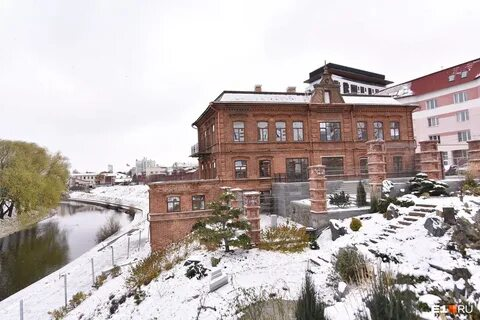

In [10]:
get_image(data_orig.sample(1)['image'].tolist()[0])

Так как в данных есть выбросы попробуем от них избавиться.
для начала воспользуемся TF-IDF для получения наиболее редких и частых слов

In [11]:
data_orig.columns

Index(['Unnamed: 0', 'Name', 'WikiData', 'City', 'Lon', 'Lat', 'description',
       'image', 'en_txt'],
      dtype='object')

In [12]:
need_cols = ['Name', 'City', 'description', 'image', 'en_txt']
data_orig = data_orig[need_cols].copy()
rows_before_dropna = len(data_orig)
data_orig = data_orig.dropna(subset=need_cols).reset_index(drop=True)
print(f'Удалено строк с пропусками: {rows_before_dropna - len(data_orig)}')
print(data_orig.shape)
data_orig.head()

Удалено строк с пропусками: 2556
(12078, 5)


,Name,City,description,image,en_txt
0,Динамо,Екатеринбург,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there are two people that are standing on a tr...
1,Динамо,Екатеринбург,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed building with a blue and white exterior...
2,Динамо,Екатеринбург,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
3,Динамо,Екатеринбург,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
4,Динамо,Екатеринбург,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a boat that is in the water near a bu...


In [13]:
display(data_orig.nunique(), data_orig.describe())

,0
Name,317
City,4
description,245
image,10922
en_txt,8137


,Name,City,description,image,en_txt
count,12078,12078,12078,12078,12078
unique,317,4,245,10922,8137
top,улица Добролюбова,Ярославль,Православный храм в Ярославле,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAICAgICAQICAg...,arafed view of a large white building with gol...
freq,87,4288,605,10,80


In [14]:
data = data_orig.groupby(['Name', 'City', 'description']).agg({'image': set, 'en_txt': set}).reset_index()
print(data.shape)
data.head()

(320, 5)


,Name,City,description,image,en_txt
0,Cerkiew Narodzenia Pańskiego w Jarosławiu,Ярославль,Православный храм в Ярославле,{/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...,{there is a small white and orange building wi...
1,Cerkiew Włodzimierskiej Ikony Matki Bożej w Ja...,Ярославль,Архитектурный ансамбль в Ярославле,{/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...,{arafed wooden structure with a steeple on top...
2,Cerkiew św. Dymitra Sołuńskiego w Jarosławiu,Ярославль,Церковь великомученика Димитрия Солунского (См...,{/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...,{there are two wooden buildings with white dom...
3,église arménienne de Vladimir,Владимир,Армянская церковь в г. Владимир России,{/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...,{a view of a large white building with a golde...
4,Авиамеханический колледж,Владимир,Владимирский авиамеханический колледж,{/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...,{there is a large building with a clock tower ...


In [15]:
list(data['en_txt'][0])

['there is a small white and orange building with two towers',
 'there is a wooden building with a steeple on the top',
 'there is a wooden church with two steeples on top of it',
 'there is a small wooden building with a steeple on top',
 'arafed wooden building with a steeple and a roof',
 'arafed wooden buildings with a steeple and a fence',
 'there is a wooden building with a wooden fence and a wooden fence',
 'arafed wooden church with a steeple and a blue roof',
 'there is a small church with two steeples on the roof',
 'there is a wooden structure with a steeple on top of it',
 'there are two wooden buildings with flags on the fence',
 'arafed wooden building with a steeple and a steeple on the top',
 'there is a small church with a steeple on the top of it',
 'there is a large wooden building with a steeple on top',
 'there are two crosses in front of a church in the woods',
 'arafed church with a green roof and a steeple',
 'arafed wooden church with a steeple and a steeple on

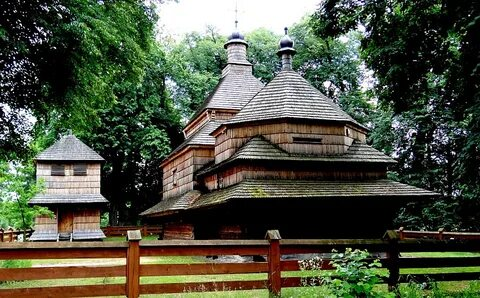

In [16]:
get_image(list(data['image'][0])[0])

In [17]:
print(f'Количество уникальных городов: {data.City.nunique()}')
data.City.value_counts()

Количество уникальных городов: 4


,count
City,
Нижний Новгород,98
Екатеринбург,97
Ярославль,96
Владимир,29


In [18]:
data.isna().mean()

,0
Name,0.0
City,0.0
description,0.0
image,0.0
en_txt,0.0


In [19]:
for i in need_cols:
    data[f'len_{i}'] = data[i].apply(lambda x: len(str(x)))
display(data.describe())

,len_Name,len_City,len_description,len_image,len_en_txt
count,320.000000,320.000000,320.000000,3.200000e+02,320.000000
mean,26.537500,11.656250,33.290625,1.714635e+06,2039.503125
std,12.935765,2.609476,21.594436,5.490707e+05,658.010552
min,4.000000,8.000000,5.000000,9.640800e+05,991.000000
25%,18.000000,9.000000,22.000000,1.307805e+06,1621.750000
50%,25.000000,12.000000,29.000000,1.510466e+06,1755.500000
75%,32.000000,15.000000,38.000000,1.989991e+06,2448.750000
max,76.000000,15.000000,225.000000,3.320324e+06,3785.000000


In [20]:
data.groupby('description').Name.count().sort_values(ascending=False).reset_index().head()

,description,Name
0,Православный храм в Ярославле,13
1,здание в Екатеринбурге,10
2,круглая башня Нижегородского кремля,8
3,музей в Екатеринбурге,8
4,памятник в Екатеринбурге,4


In [21]:
# Загрузка предтренировочной модели для машинного перевода

MODEL_TRANS_NAME = "facebook/mbart-large-50-many-to-many-mmt"
SRC_LANG = "ru_RU"  # Код языка для русского
TRG_LANG = "en_XX"   # Код языка для английского

# Функция для перевода текста
def translate(model_trans,
              tokenizer_trans,
              text:str,
              src:str=SRC_LANG,
              dest:str=TRG_LANG):
    """
    Функция для перевода текста
        model_trans - предобученная модель машинного перевода
        tokenizer_trans - токенизатор модели
        text:str - текст для перевода
        src:str - код языка с которого необходимо перевести
        dest:str - код языка на который необходимо перевести
    """
    tokenizer_trans.src_lang = src
    encoded_input = tokenizer_trans(text, return_tensors="pt").to(DEVICE)


    generated_tokens = model_trans.generate(**encoded_input, forced_bos_token_id=tokenizer_trans.lang_code_to_id[dest])

    return tokenizer_trans.batch_decode(generated_tokens, skip_special_tokens=True)[0]


try:
    MODEL_TRANS = MBartForConditionalGeneration.from_pretrained(MODEL_TRANS_NAME).to(DEVICE)
    TOKENIZER_TRANS = MBart50TokenizerFast.from_pretrained(MODEL_TRANS_NAME)
    print(f"Модель и токенизатор загружены успешно!")
except Exception as e:
    print(f"Ошибка при загрузке: {e}")

config.json:   0%|          | 0.00/1.43k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.44GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/516 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/261 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/529 [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/649 [00:00<?, ?B/s]

Модель и токенизатор загружены успешно!


In [22]:
# Проверка кода
source_text = data['description'][0] # первое описние из датасета
translated_text = translate(MODEL_TRANS, TOKENIZER_TRANS, source_text)
print(f'На русском: {source_text} \nНа английском: {translated_text}')

На русском: Православный храм в Ярославле 
На английском: Orthodox Church in Yaroslavl


In [23]:
%%time

ru_corpus = set(data.description)
trans_ru_to_en = {k:v for k, v in zip(ru_corpus, [translate(model_trans=MODEL_TRANS,
                                                            tokenizer_trans=TOKENIZER_TRANS,
                                                            text=x) for i, x in tqdm(enumerate(ru_corpus))])}
data['en_description'] = data['description'].map(trans_ru_to_en)

# Перевод завершён: освобождаем GPU-память перед embedding-моделью и LLM.
del MODEL_TRANS, TOKENIZER_TRANS
if torch.cuda.is_available():
    torch.cuda.empty_cache()

0it [00:00, ?it/s]

CPU times: user 1min 7s, sys: 229 ms, total: 1min 7s
Wall time: 1min 23s


In [24]:
need_cols = ['Name', 'City', 'description', 'image', 'en_txt', 'en_description']
data_filterd = data[need_cols].copy()
print(data_filterd.shape)
data_filterd.head()

(320, 6)


,Name,City,description,image,en_txt,en_description
0,Cerkiew Narodzenia Pańskiego w Jarosławiu,Ярославль,Православный храм в Ярославле,{/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...,{there is a small white and orange building wi...,Orthodox Church in Yaroslavl
1,Cerkiew Włodzimierskiej Ikony Matki Bożej w Ja...,Ярославль,Архитектурный ансамбль в Ярославле,{/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...,{arafed wooden structure with a steeple on top...,Architectural ensemble in Yaroslavl
2,Cerkiew św. Dymitra Sołuńskiego w Jarosławiu,Ярославль,Церковь великомученика Димитрия Солунского (См...,{/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...,{there are two wooden buildings with white dom...,Church of St. Demetrius of Alexandria (Smolens...
3,église arménienne de Vladimir,Владимир,Армянская церковь в г. Владимир России,{/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...,{a view of a large white building with a golde...,"Armenian Church in Vladimir, Russia"
4,Авиамеханический колледж,Владимир,Владимирский авиамеханический колледж,{/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...,{there is a large building with a clock tower ...,Vladimir Aviation Mechanical College


In [25]:
ENG_STOP_WORDS = list(set(stopwords.words('english')))
RUS_STOP_WORDS = list(set(stopwords.words('russian')))
STOP_WORDS = ENG_STOP_WORDS + RUS_STOP_WORDS
STOP_WORDS.append('none')
PUNCT_WORD_TOKENIZER = nltk.WordPunctTokenizer()
MORPH_ANALYZER = pymorphy3.MorphAnalyzer()

def preprocess_text(text, norm_tokens: bool=True, stopwords: set=(), del_ru: bool=True):
    """
    Функция предобработки текста
        text - текст
        norm_tokens - флаг нормализации текста
        stopwords - стопслова
        del_ru - необходимость удалять русские слова или наоборот
    """
    nums_filtered_text = re.sub(r'[0-9]+', '', text.lower())
    if del_ru:
        word_filtered_text = re.sub(r'[^a-zA-Z\s]+', '', nums_filtered_text)
    else:
        word_filtered_text = re.sub(r'[a-zA-Z]+', '', nums_filtered_text)
    punct_filtered_text = ''.join([ch for ch in word_filtered_text if ch
                                   not in string.punctuation])
    tokens = PUNCT_WORD_TOKENIZER.tokenize(punct_filtered_text)
    if len(stopwords) != 0:
      tokens = [MORPH_ANALYZER.parse(token)[0].normal_form for token in tokens
                if token not in stopwords]
    if norm_tokens:
        tokens = [MORPH_ANALYZER.parse(token)[0].normal_form for token in tokens]

    return ' '.join(tokens)


def unique_words(text):
    """
    Функция извлечения уникальных слов из текста
        text - текст
    """
    words = text.split()
    unique_words = list(set(words))
    return ' '.join(unique_words)

In [26]:
data_filterd['image'] = data_filterd.image.apply(lambda x: list(x))
data_filterd['all_en_txt'] = data_filterd.en_txt.apply(lambda x: ' '.join(list(x)))
data_filterd['all_en_txt'] = data_filterd[['en_description', 'all_en_txt']].apply(lambda x: ' '.join(x), axis=1)

data_filterd['processed_text'] = (data_filterd['all_en_txt']
                                  .apply(lambda x: preprocess_text(text=x
                                                                   , norm_tokens = True
                                                                   , stopwords=STOP_WORDS
                                                                   )
                                         )
                                  )

data_filterd['unique_processed_text'] = (data_filterd['processed_text']
                                         .apply(lambda x: unique_words(text=x)
                                                )
                                         )

print(data_filterd.shape)
data_filterd.head(2)

(320, 9)


,Name,City,description,image,en_txt,en_description,all_en_txt,processed_text,unique_processed_text
0,Cerkiew Narodzenia Pańskiego w Jarosławiu,Ярославль,Православный храм в Ярославле,[/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...,{there is a small white and orange building wi...,Orthodox Church in Yaroslavl,Orthodox Church in Yaroslavl there is a small ...,orthodox church yaroslavl small white orange b...,front middle church orthodox crosses orange cr...
1,Cerkiew Włodzimierskiej Ikony Matki Bożej w Ja...,Ярославль,Архитектурный ансамбль в Ярославле,[/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...,{arafed wooden structure with a steeple on top...,Architectural ensemble in Yaroslavl,Architectural ensemble in Yaroslavl arafed woo...,architectural ensemble yaroslavl arafed wooden...,front background many domes table church icons...


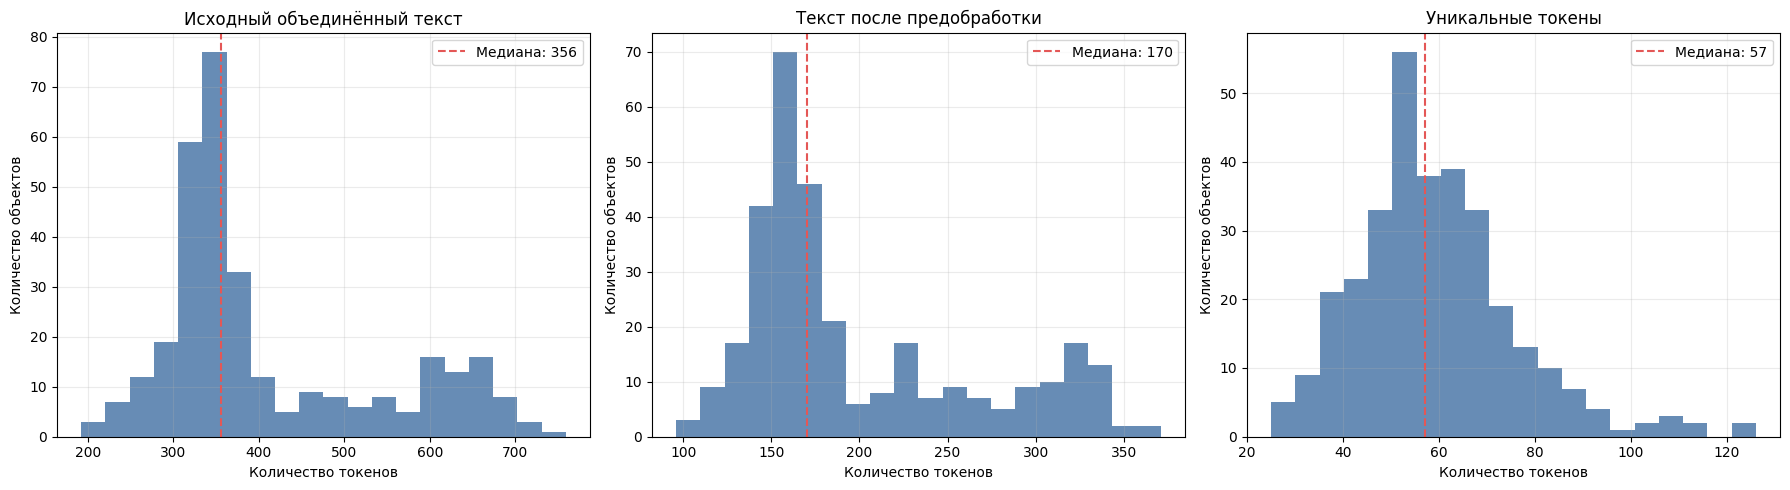

,num_tokens_of_all_en_txt,num_tokens_of_processed_text,num_tokens_of_unique_processed_text
count,320.00000,320.000000,320.000000
mean,410.14375,198.193750,59.484375
std,129.83099,65.650351,16.532283
min,192.00000,96.000000,25.000000
25%,324.00000,153.000000,49.000000
50%,356.00000,170.000000,57.000000
75%,488.75000,234.000000,69.000000
max,759.00000,371.000000,126.000000


In [27]:
token_columns = {
    'all_en_txt': 'Исходный объединённый текст',
    'processed_text': 'Текст после предобработки',
    'unique_processed_text': 'Уникальные токены',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (column, title) in zip(axes, token_columns.items()):
    count_column = f'num_tokens_of_{column}'
    data_filterd[count_column] = data_filterd[column].apply(
        lambda text: len(PUNCT_WORD_TOKENIZER.tokenize(text))
    )
    median = data_filterd[count_column].median()
    ax.hist(data_filterd[count_column], bins=20, color='#4C78A8', alpha=0.85)
    ax.axvline(median, color='#E45756', linestyle='--', label=f'Медиана: {median:.0f}')
    ax.set_title(title)
    ax.set_xlabel('Количество токенов')
    ax.set_ylabel('Количество объектов')
    ax.grid(alpha=0.25)
    ax.legend()

plt.tight_layout()
plt.show()
data_filterd[list(f'num_tokens_of_{column}' for column in token_columns)].describe()

In [28]:
corpus_txt = data_filterd.unique_processed_text.tolist()

vectorizer = TfidfVectorizer(ngram_range=(1,2))

# Применение TF-IDF к текстовым данным
matrix = vectorizer.fit_transform(corpus_txt)
feature_names = vectorizer.get_feature_names_out()

all_score_df = (pd.DataFrame({'word': feature_names,
                              'score': matrix.toarray().sum(axis=0)})
                .sort_values('score')).reset_index(drop=True)
all_score_df

,word,score
0,door project,0.078067
1,technikym,0.078067
2,teacher,0.078067
3,teacher people,0.078067
4,man parking,0.078067
...,...,...
9506,arafed,7.647703
9507,building,7.665399
9508,large,7.673177
9509,tower,7.698777


In [29]:
def show_contains(df: pd.DataFrame,
                  column: str,
                  word: str):
    """
    Функция отображения контекта по входящему выражения
        df - датафрейм
        column - столбец, по которому проверяем вхождение
        word - слово / предложение, которое проверяем в column
    """

    df = df[df[column].str.contains(word)]
    name = df.Name.values[0]
    len_images = len(df['image'].values[0])

    display(df.head(3),
            print(f'Наименование объекта: {name}, количество картинок: {len_images}'),
        get_image(df['image'].values[0][np.random.randint(0,len_images)]))

Наименование объекта: Автомеханический техникум, количество картинок: 56


,Name,City,description,image,en_txt,en_description,all_en_txt,processed_text,unique_processed_text,num_tokens_of_all_en_txt,num_tokens_of_processed_text,num_tokens_of_unique_processed_text
6,Автомеханический техникум,Ярославль,образовательное учреждение в Ярославле,[/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...,"{arafed man working on a machine in a factory,...",educational institution in Yaroslavl,educational institution in Yaroslavl arafed ma...,educational institution yaroslavl arafed man w...,banner front many table organization certifica...,624,306,126


None

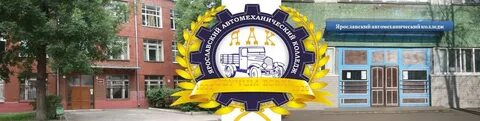

In [30]:
show_contains(data_filterd, 'unique_processed_text', all_score_df['word'][0])

Наименование объекта: Автомеханический техникум, количество картинок: 56


,Name,City,description,image,en_txt,en_description,all_en_txt,processed_text,unique_processed_text,num_tokens_of_all_en_txt,num_tokens_of_processed_text,num_tokens_of_unique_processed_text
6,Автомеханический техникум,Ярославль,образовательное учреждение в Ярославле,[/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...,"{arafed man working on a machine in a factory,...",educational institution in Yaroslavl,educational institution in Yaroslavl arafed ma...,educational institution yaroslavl arafed man w...,banner front many table organization certifica...,624,306,126


None

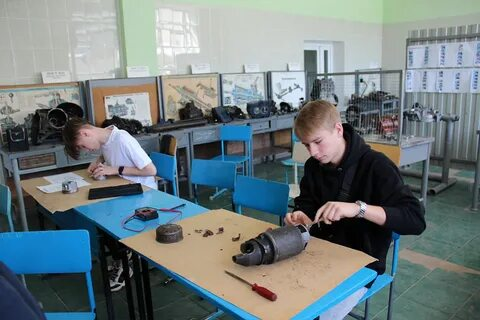

In [31]:
show_contains(data_filterd, 'unique_processed_text', all_score_df['word'][1])

Наименование объекта: Cerkiew Włodzimierskiej Ikony Matki Bożej w Jarosławiu, количество картинок: 59


,Name,City,description,image,en_txt,en_description,all_en_txt,processed_text,unique_processed_text,num_tokens_of_all_en_txt,num_tokens_of_processed_text,num_tokens_of_unique_processed_text
1,Cerkiew Włodzimierskiej Ikony Matki Bożej w Ja...,Ярославль,Архитектурный ансамбль в Ярославле,[/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...,{arafed wooden structure with a steeple on top...,Architectural ensemble in Yaroslavl,Architectural ensemble in Yaroslavl arafed woo...,architectural ensemble yaroslavl arafed wooden...,front background many domes table church icons...,653,322,96
2,Cerkiew św. Dymitra Sołuńskiego w Jarosławiu,Ярославль,Церковь великомученика Димитрия Солунского (См...,[/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...,{there are two wooden buildings with white dom...,Church of St. Demetrius of Alexandria (Smolens...,Church of St. Demetrius of Alexandria (Smolens...,church st demetrius alexandria smolensk yarosl...,front domes church cross grassy old walkway ar...,644,304,77
3,église arménienne de Vladimir,Владимир,Армянская церковь в г. Владимир России,[/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...,{a view of a large white building with a golde...,"Armenian Church in Vladimir, Russia","Armenian Church in Vladimir, Russia a view of ...",armenian church vladimir russia view large whi...,front bright background head sun close generat...,362,164,75


None

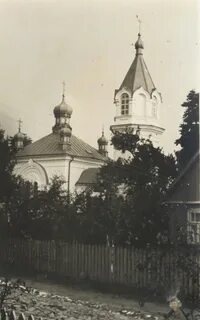

In [32]:
show_contains(data_filterd, 'unique_processed_text', all_score_df['word'].iloc[-1])

In [33]:
vectorizer = TfidfVectorizer(ngram_range=(1,2),
                             min_df=0.1)

# Применение TF-IDF к текстовым данным
matrix = vectorizer.fit_transform(corpus_txt)
feature_names = vectorizer.get_feature_names_out()

need_score_df = (pd.DataFrame({'word': feature_names,
                               'score': matrix.toarray().sum(axis=0)})
                 .sort_values('score'))
need_score_df

,word,score
35,church side,6.407839
11,bell,6.445035
28,carriage,6.580214
156,train,6.680247
10,bed,6.730575
...,...,...
39,clock,20.800341
79,large,21.046136
60,front,21.203255
21,building,21.314946


Попробую определить выбросы с помощью K-Means
для оптимального выбора k воспользуемся методом локтя и silhouette

In [34]:
def choose_optimal_k_elbow(data, min_k: int=4, devide: int=10, step: int=100, selected_k: int=6):
    """
    Функция определения оптимального количества кластеров по метрикам kmeans_score и silhouette
        data - датафрейм / матрица
        min_k - минимальное количество кластеров
        devide - значение делитель размера датафрейма
        step - шаг добавления кластеров
    """
    k_scores = []
    s_scores = []

    k_max = int(data.shape[0]/devide)

    k_values = range(min_k, k_max, step)

    for k in tqdm(k_values):
        kmeans = KMeans(n_clusters=k,
                        init='k-means++',
                        n_init=10,
                        max_iter=300,
                        tol=0.0001,
                        random_state=SEED)

        preds = kmeans.fit_predict(data)

        k_scores.append(-kmeans.score(data))

        # Silhouette Score
        silhouette = silhouette_score(data, preds)
        s_scores.append(silhouette)

    metrics = pd.DataFrame({
        'k': list(k_values),
        'inertia': k_scores,
        'silhouette': s_scores,
    })

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(metrics['k'], metrics['inertia'], marker='o')
    axes[0].axvline(selected_k, color='#E45756', linestyle='--', label=f'Выбрано k={selected_k}')
    axes[0].set_title('Метод локтя')
    axes[0].set_xlabel('Количество кластеров')
    axes[0].set_ylabel('Inertia')
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    axes[1].plot(metrics['k'], metrics['silhouette'], marker='o')
    axes[1].axvline(selected_k, color='#E45756', linestyle='--', label=f'Выбрано k={selected_k}')
    axes[1].set_title('Качество разделения кластеров')
    axes[1].set_xlabel('Количество кластеров')
    axes[1].set_ylabel('Silhouette score')
    axes[1].grid(alpha=0.25)
    axes[1].legend()

    plt.tight_layout()
    plt.show()
    return metrics

  0%|          | 0/17 [00:00<?, ?it/s]

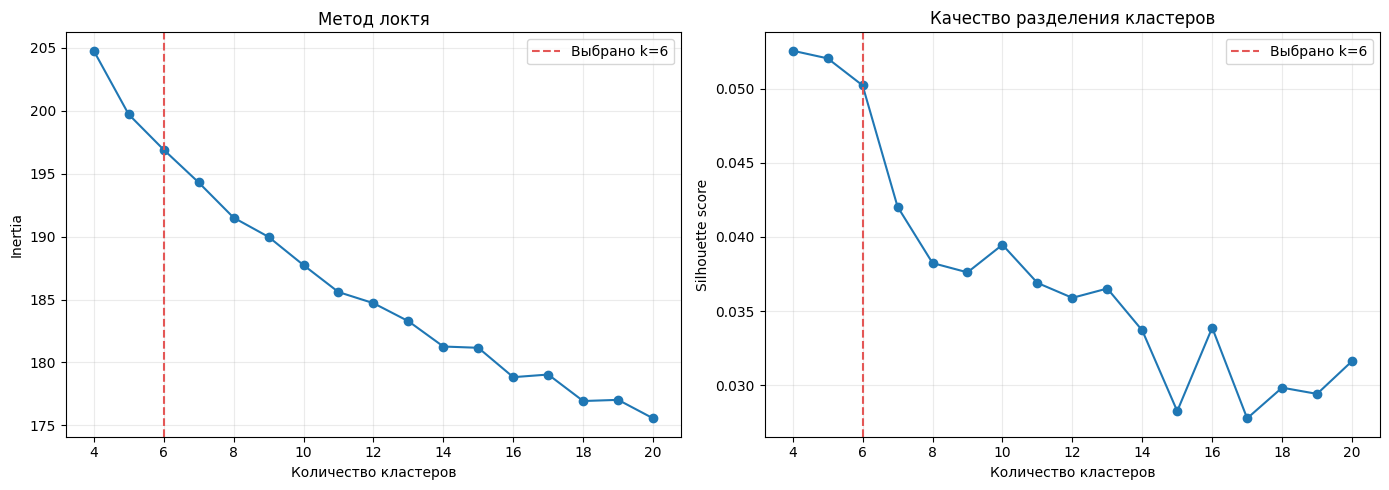

,k,inertia,silhouette
0,4,204.7706,0.0526
1,5,199.7100,0.0521
2,6,196.9083,0.0502
3,7,194.3059,0.0420
4,8,191.5090,0.0382
5,9,189.9806,0.0376
6,10,187.7373,0.0395
7,11,185.5969,0.0369
8,12,184.7139,0.0359
9,13,183.2817,0.0365


In [35]:
k_metrics = choose_optimal_k_elbow(matrix, devide=15, step=1, selected_k=6)
display(k_metrics.round(4))

In [36]:
km_clustering = KMeans(
    n_clusters=6,
    init='k-means++',
    n_init=10,
    max_iter=300,
    tol=0.0001,
    random_state=SEED)

data_filterd['prediction'] = km_clustering.fit_predict(matrix)
prediction_counts = (data_filterd['prediction']
                     .value_counts()
                     .sort_values()
                     .reset_index()
                     .rename(columns={'count':'v_counts'})
                    )
prediction_counts.head()

,prediction,v_counts
0,3,36
1,0,44
2,1,46
3,2,51
4,5,54


In [37]:
prediction_counts.describe()

,prediction,v_counts
count,6.000000,6.000000
mean,2.500000,53.333333
std,1.870829,18.543642
min,0.000000,36.000000
25%,1.250000,44.500000
50%,2.500000,48.500000
75%,3.750000,53.250000
max,5.000000,89.000000


In [38]:
# 10% кластеров по value_counts и сортировке
need_clusters = (prediction_counts[prediction_counts['v_counts']
                 >=prediction_counts['v_counts'].quantile(0.1)]
                 .prediction)

# Посмотрим как меняется количество наблюдений после фильтрации
print(data_filterd.shape,
      data_filterd[data_filterd['prediction'].isin(need_clusters)].shape)

(320, 13) (284, 13)


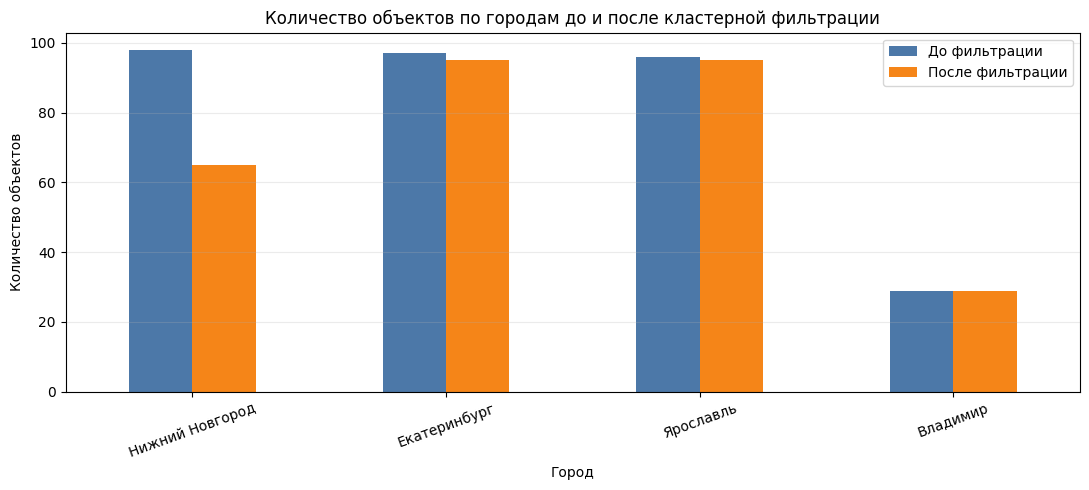

,До фильтрации,После фильтрации
City,,
Нижний Новгород,98,65
Екатеринбург,97,95
Ярославль,96,95
Владимир,29,29


In [39]:
city_counts = pd.concat(
    [
        data_filterd['City'].value_counts().rename('До фильтрации'),
        data_filterd[data_filterd['prediction'].isin(need_clusters)]['City'].value_counts().rename('После фильтрации'),
    ],
    axis=1,
).fillna(0).astype(int)

ax = city_counts.plot(kind='bar', figsize=(11, 5), color=['#4C78A8', '#F58518'])
ax.set_title('Количество объектов по городам до и после кластерной фильтрации')
ax.set_xlabel('Город')
ax.set_ylabel('Количество объектов')
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()
display(city_counts)

In [40]:
data_filterd = data_filterd[data_filterd['prediction'].isin(need_clusters)]
print(data_filterd.shape)
data_filterd.head()

(284, 13)


,Name,City,description,image,en_txt,en_description,all_en_txt,processed_text,unique_processed_text,num_tokens_of_all_en_txt,num_tokens_of_processed_text,num_tokens_of_unique_processed_text,prediction
0,Cerkiew Narodzenia Pańskiego w Jarosławiu,Ярославль,Православный храм в Ярославле,[/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...,{there is a small white and orange building wi...,Orthodox Church in Yaroslavl,Orthodox Church in Yaroslavl there is a small ...,orthodox church yaroslavl small white orange b...,front middle church orthodox crosses orange cr...,265,130,30,4
1,Cerkiew Włodzimierskiej Ikony Matki Bożej w Ja...,Ярославль,Архитектурный ансамбль в Ярославле,[/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...,{arafed wooden structure with a steeple on top...,Architectural ensemble in Yaroslavl,Architectural ensemble in Yaroslavl arafed woo...,architectural ensemble yaroslavl arafed wooden...,front background many domes table church icons...,653,322,96,4
2,Cerkiew św. Dymitra Sołuńskiego w Jarosławiu,Ярославль,Церковь великомученика Димитрия Солунского (См...,[/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...,{there are two wooden buildings with white dom...,Church of St. Demetrius of Alexandria (Smolens...,Church of St. Demetrius of Alexandria (Smolens...,church st demetrius alexandria smolensk yarosl...,front domes church cross grassy old walkway ar...,644,304,77,4
3,église arménienne de Vladimir,Владимир,Армянская церковь в г. Владимир России,[/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...,{a view of a large white building with a golde...,"Armenian Church in Vladimir, Russia","Armenian Church in Vladimir, Russia a view of ...",armenian church vladimir russia view large whi...,front bright background head sun close generat...,362,164,75,4
4,Авиамеханический колледж,Владимир,Владимирский авиамеханический колледж,[/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...,{there is a large building with a clock tower ...,Vladimir Aviation Mechanical College,Vladimir Aviation Mechanical College there is ...,vladimir aviation mechanical college large bui...,front college arafexibular driving parked many...,343,167,64,1


In [41]:
data_filterd.City.value_counts()

,count
City,
Ярославль,95
Екатеринбург,95
Нижний Новгород,65
Владимир,29


In [42]:
data_filterd.City.value_counts()

,count
City,
Ярославль,95
Екатеринбург,95
Нижний Новгород,65
Владимир,29


In [43]:
for i in ['Name', 'City', 'description']:
    data_filterd[f'len_{i}'] = data_filterd[i].apply(lambda x: len(str(x)))
display(data_filterd.describe())

,num_tokens_of_all_en_txt,num_tokens_of_processed_text,num_tokens_of_unique_processed_text,prediction,len_Name,len_City,len_description
count,284.000000,284.000000,284.000000,284.000000,284.000000,284.000000,284.000000
mean,412.218310,198.158451,60.330986,2.725352,27.151408,11.274648,32.926056
std,129.521823,66.140333,16.607598,1.797699,13.323707,2.489964,22.517166
min,192.000000,96.000000,27.000000,0.000000,4.000000,8.000000,5.000000
25%,328.500000,153.000000,50.000000,1.000000,18.000000,9.000000,21.000000
50%,358.000000,170.000000,58.000000,4.000000,25.000000,12.000000,29.000000
75%,486.250000,234.000000,69.000000,4.000000,32.250000,12.000000,38.000000
max,759.000000,371.000000,126.000000,5.000000,76.000000,15.000000,225.000000


In [44]:
data_filterd[data_filterd.len_description==5]

,Name,City,description,image,en_txt,en_description,all_en_txt,processed_text,unique_processed_text,num_tokens_of_all_en_txt,num_tokens_of_processed_text,num_tokens_of_unique_processed_text,prediction,len_Name,len_City,len_description
130,Литературная жизнь Урала XX века,Екатеринбург,Музей,[/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...,{arafed brick building with a steeple and a ma...,Museum,Museum arafed brick building with a steeple an...,museum arafed brick building steeple man walki...,front background display parked museum cars br...,274,124,54,5,32,12,5


не удалось избавиться от всех выбросов, поэтому оставшиеся попробую удалить вручную

### Ручная отчистка

In [45]:
(
    data_filterd.Name.nunique(),
    data_filterd.Name.unique().tolist())

(282,
 ['Cerkiew Narodzenia Pańskiego w Jarosławiu',
  'Cerkiew Włodzimierskiej Ikony Matki Bożej w Jarosławiu',
  'Cerkiew św. Dymitra Sołuńskiego w Jarosławiu',
  'église arménienne de Vladimir',
  'Авиамеханический колледж',
  'Автозаводский парк культуры и отдыха',
  'Автомеханический техникум',
  'Администрация Нижнего Новгорода',
  'Александро-Невская часовня',
  'Александро-Невский собор',
  'Белая башня',
  'Белокаменные памятники Владимира и Суздаля',
  'Беседка на Волжской набережной',
  'Блиновский пассаж',
  'Богородице-Рождественский мужской монастырь',
  'Богоявленская башня',
  'Больница имени Н. В. Соловьёва',
  'Бутусовский посёлок',
  'Бывшая водонапорная башня',
  'Вечный огонь (Ярославль)',
  'Владимиро-Суздальский музей-заповедник (центральный офис)',
  'Владимирская духовная семинария',
  'Владимирская митрополия',
  'Владимирская церковь',
  'Владимирский академический областной драматический театр',
  'Владимирский государственный гуманитарный университет',
  'В

Наименование объекта: Школа № 33 имени Карла Маркса, количество картинок: 60


,Name,City,description,image,en_txt,en_description,all_en_txt,processed_text,unique_processed_text,num_tokens_of_all_en_txt,num_tokens_of_processed_text,num_tokens_of_unique_processed_text,prediction,len_Name,len_City,len_description
289,Школа № 33 имени Карла Маркса,Ярославль,Школа № 33 имени Карла Маркса,[/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...,{there is a building with a sign on the front ...,Karl Marx School No. 33,Karl Marx School No. 33 there is a building wi...,karl marx school building sign front large bui...,front background many fenced taking speak wind...,722,314,125,5,29,9,29


None

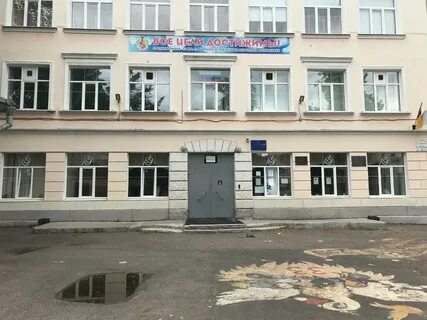

In [46]:
show_contains(data_filterd, 'Name', 'Школа № 33 имени Карла Маркса')

In [47]:
drop_names = [
    'Автомеханический техникум',
    'Администрация Нижнего Новгорода',
    'Больница имени Н. В. Соловьёва',
    'Нижегородское речное училище',
    'Рекорд',
    'Школа № 33 имени Карла Маркса',
]

found_names = sorted(set(drop_names) & set(data_filterd['Name']))
missing_names = sorted(set(drop_names) - set(data_filterd['Name']))
print('Будут удалены:', found_names)
print('Не найдены:', missing_names)

Будут удалены: ['Автомеханический техникум', 'Администрация Нижнего Новгорода', 'Больница имени Н. В. Соловьёва', 'Нижегородское речное училище', 'Рекорд', 'Школа № 33 имени Карла Маркса']
Не найдены: []


In [48]:
data_filterd = data_filterd[~data_filterd.Name.isin(drop_names)].reset_index(drop=True)
print(data_filterd.shape)
data_filterd.head(2)

(278, 16)


,Name,City,description,image,en_txt,en_description,all_en_txt,processed_text,unique_processed_text,num_tokens_of_all_en_txt,num_tokens_of_processed_text,num_tokens_of_unique_processed_text,prediction,len_Name,len_City,len_description
0,Cerkiew Narodzenia Pańskiego w Jarosławiu,Ярославль,Православный храм в Ярославле,[/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...,{there is a small white and orange building wi...,Orthodox Church in Yaroslavl,Orthodox Church in Yaroslavl there is a small ...,orthodox church yaroslavl small white orange b...,front middle church orthodox crosses orange cr...,265,130,30,4,41,9,29
1,Cerkiew Włodzimierskiej Ikony Matki Bożej w Ja...,Ярославль,Архитектурный ансамбль в Ярославле,[/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...,{arafed wooden structure with a steeple on top...,Architectural ensemble in Yaroslavl,Architectural ensemble in Yaroslavl arafed woo...,architectural ensemble yaroslavl arafed wooden...,front background many domes table church icons...,653,322,96,4,54,9,34


In [49]:
SAVE = True
if SAVE:
    data_filterd.to_csv('data_filterd.csv', index=False)
else:
    data_filterd = pd.read_csv('data_filterd.csv')

---

## Векторная база данных

In [50]:
# Передаем контент и метаинформацию в LangchainDocument

RAW_KNOWNLEDGE_BASE = [
    LangchainDocument(
        page_content=(
            data_filterd['Name'][i] + ': ' + data_filterd['description'][i]
            + ' (город: ' + data_filterd['City'][i] + ')'
        ),
        metadata={"City": data_filterd["City"][i]
#                  , "image": data_filterd["image"][i]
                 })
    for i in tqdm(range(len(data_filterd)))
]

  0%|          | 0/278 [00:00<?, ?it/s]

In [51]:
# Мы используем иерархический список разделителей, специально предназначенных для разделения документов Markdown
# Этот список взят из класса MarkdownTextSplitter в LangChain

MARKDOWN_SEPARATORS = [
    "\n#{1,6} ",
    "```\n",
    "\n\\*\\*\\*+\n",
    "\n---+\n",
    "\n___+\n",
    "\n\n",
    "\n",
    " ",
    "",
]

CHUNK_SIZE = 512

TEXT_SPLITTER = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,  # Максимальное количество символов в чанке
    chunk_overlap=int(CHUNK_SIZE * 0.1),  # Количество символов, которые будут перекрываться между чанками
    add_start_index=True,  # Если "True", то включает начальный индекс чанка в метаданные
    strip_whitespace=True,  # Если значение "True", то пробелы удаляются из начала и конца каждого документа
    separators=MARKDOWN_SEPARATORS,
)

docs_processed = []
for doc in RAW_KNOWNLEDGE_BASE:
    docs_processed += TEXT_SPLITTER.split_documents([doc])

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

Embedding model's maximum sequence length: 512


  0%|          | 0/278 [00:00<?, ?it/s]

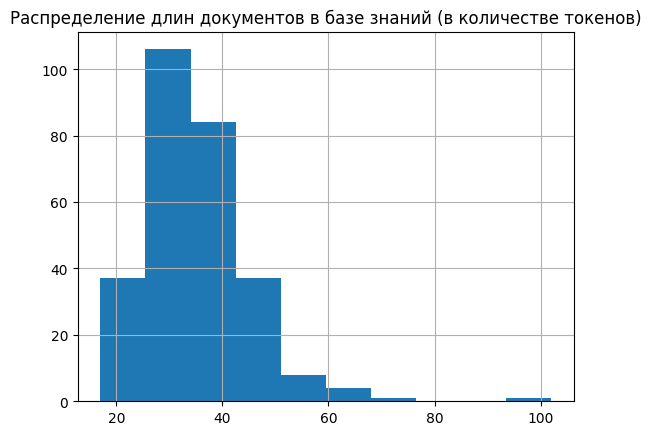

In [52]:
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
EMBEDDING_MODEL_NAME = "intfloat/multilingual-e5-small"

TOKENIZER = AutoTokenizer.from_pretrained(MODEL_NAME,
#                                          max_length=1024
                                         )

# Проверяем параметры embedding-модели и сразу освобождаем временную копию.
embedding_info_model = SentenceTransformer(EMBEDDING_MODEL_NAME, device=DEVICE)
print(f"Embedding model's maximum sequence length: {embedding_info_model.max_seq_length}")
del embedding_info_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()
lengths = [len(TOKENIZER.encode(doc.page_content)) for doc in tqdm(docs_processed)]

# Построим график распределения длин документов, подсчитываемых как количество токенов
fig = pd.Series(lengths).hist()
plt.title("Распределение длин документов в базе знаний (в количестве токенов)")
plt.show()

In [53]:
def create_embedding_model(model_name):
    """
    Функция создания ембеддинг модели
    """
    try:
        embedding_model = HuggingFaceEmbeddings(
            model_name=model_name,
            multi_process=False,
            model_kwargs={"device": DEVICE},
            encode_kwargs={"normalize_embeddings": True, "batch_size": 32},
        )

        print(f"Embedding model created")
        return embedding_model

    except Exception as e:
        print(f"Error creating embedding model: {str(e)}")
        return None

In [54]:
%%time

EMBEDDING_MODEL = create_embedding_model(EMBEDDING_MODEL_NAME)
if EMBEDDING_MODEL is None:
    raise RuntimeError('Embedding-модель не была создана')

try:
    KNOWNLEDGE_VECTOR_DATABASE = Chroma.from_documents(
        documents=docs_processed,
        embedding=EMBEDDING_MODEL,
    )
    print(f'Vector database created: {len(docs_processed)} документов')
except Exception as error:
    raise RuntimeError(f'Не удалось создать векторную базу: {error}') from error

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Embedding model created
Vector database created: 278 документов
CPU times: user 4.6 s, sys: 472 ms, total: 5.07 s
Wall time: 7.69 s


### Визуализация пространства документов
PCA показывает линейную структуру и долю объяснённой дисперсии, UMAP — локальное соседство объектов. Цвета городов одинаковы на обоих графиках.

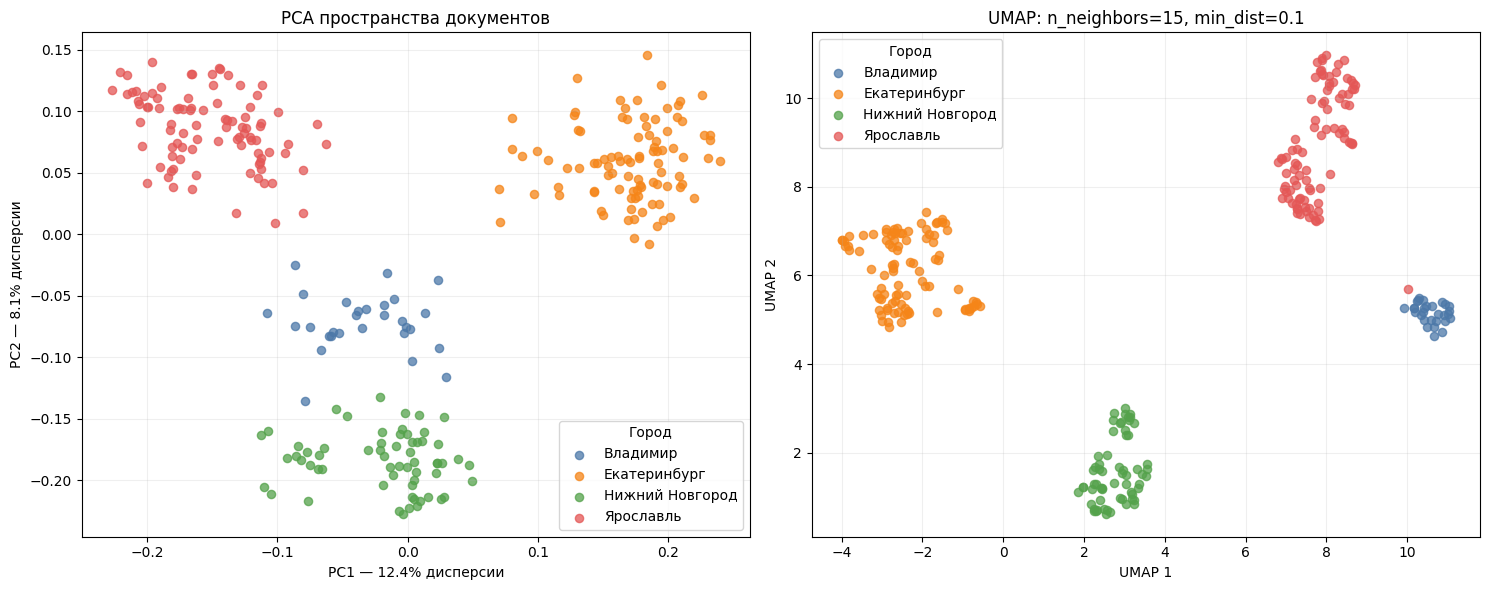

In [55]:
document_texts = [doc.page_content for doc in docs_processed]
document_cities = [doc.metadata['City'] for doc in docs_processed]
document_embeddings = np.asarray(EMBEDDING_MODEL.embed_documents(document_texts))

pca_model = PCA(n_components=2, random_state=SEED)
pca_points = pca_model.fit_transform(document_embeddings)

umap_model = umap.UMAP(
    n_components=2, n_neighbors=15, min_dist=0.1, metric='cosine', random_state=SEED
)
umap_points = umap_model.fit_transform(document_embeddings)

city_order = sorted(set(document_cities))
palette = dict(zip(city_order, ['#4C78A8', '#F58518', '#54A24B', '#E45756']))
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for city in city_order:
    mask = np.asarray(document_cities) == city
    axes[0].scatter(pca_points[mask, 0], pca_points[mask, 1], s=35, alpha=0.75, label=city, color=palette[city])
    axes[1].scatter(umap_points[mask, 0], umap_points[mask, 1], s=35, alpha=0.75, label=city, color=palette[city])

variance = pca_model.explained_variance_ratio_ * 100
axes[0].set_title('PCA пространства документов')
axes[0].set_xlabel(f'PC1 — {variance[0]:.1f}% дисперсии')
axes[0].set_ylabel(f'PC2 — {variance[1]:.1f}% дисперсии')
axes[1].set_title('UMAP: n_neighbors=15, min_dist=0.1')
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')
for ax in axes:
    ax.grid(alpha=0.2)
    ax.legend(title='Город')
plt.tight_layout()
plt.show()

In [56]:
# Вставляем пользовательский запрос в то же пространство
user_query = "Что можно посмотреть в Екатеринбурге?"
query_vector = EMBEDDING_MODEL.embed_query(user_query)

In [57]:
print(f"\nStarting retrieval for {user_query=}...")
retrieved_docs = KNOWNLEDGE_VECTOR_DATABASE.similarity_search(query=user_query, k=10)

print("\n==================================Топ похожих документов==================================")
for i in tqdm(range(len(retrieved_docs))):
    print(i, ' - '.join([retrieved_docs[i].metadata['City'],
                         retrieved_docs[i].page_content]))
    print('='*50)


Starting retrieval for user_query='Что можно посмотреть в Екатеринбурге?'...

==================================Топ похожих документов==================================


  0%|          | 0/10 [00:00<?, ?it/s]

0 Екатеринбург - Музей истории Екатеринбурга: музей в Екатеринбурге (город: Екатеринбург)
1 Екатеринбург - Музей изобразительных искусств: музей в Екатеринбурге (город: Екатеринбург)
2 Екатеринбург - Екатеринбургский музей изобразительных искусств: музей в Екатеринбурге (город: Екатеринбург)
3 Екатеринбург - №19 Музей истории Екатеринбурга: музей в Екатеринбурге (город: Екатеринбург)
4 Екатеринбург - Музей «Литературная жизнь Урала XIX века»: Литературный музей в Екатеринбурге (город: Екатеринбург)
5 Екатеринбург - Литературная жизнь Урала XX века: Музей (город: Екатеринбург)
6 Екатеринбург - Уральский геологический музей: музей в Екатеринбурге (город: Екатеринбург)
7 Екатеринбург - Художественный Музей Эрнста Неизвестного: музей в Екатеринбурге (город: Екатеринбург)
8 Екатеринбург - Дом Э. Ф. Филитц: здание и достопримечательность в Екатеринбурге (город: Екатеринбург)
9 Екатеринбург - Ленин: памятник в Екатеринбурге (город: Екатеринбург)


In [58]:
RERANKER = None
print('Reranker отключён: используется dense retrieval Chroma')

print(f"\nStarting retrieval for {user_query=}...")
relevant_docs = [doc.page_content for doc in retrieved_docs]
relevant_docs = [
    {'content': content, 'score': None, 'rank': rank}
    for rank, content in enumerate(relevant_docs[:5])
]

print("==================================Топ 1 проранжированный документ==================================")
print(relevant_docs[0])

Reranker отключён: используется dense retrieval Chroma

Starting retrieval for user_query='Что можно посмотреть в Екатеринбурге?'...
==================================Топ 1 проранжированный документ==================================
{'content': 'Музей истории Екатеринбурга: музей в Екатеринбурге (город: Екатеринбург)', 'score': None, 'rank': 0}


Наименование объекта: Музей истории Екатеринбурга, количество картинок: 29


,Name,City,description,image,en_txt,en_description,all_en_txt,processed_text,unique_processed_text,num_tokens_of_all_en_txt,num_tokens_of_processed_text,num_tokens_of_unique_processed_text,prediction,len_Name,len_City,len_description
127,Музей истории Екатеринбурга,Екатеринбург,музей в Екатеринбурге,[/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...,{there is a building with a sign on the front ...,Museum in Yekaterinburg,Museum in Yekaterinburg there is a building wi...,museum yekaterinburg building sign front build...,arafective front door walls fancy background m...,330,145,60,5,27,12,21
272,№19 Музей истории Екатеринбурга,Екатеринбург,музей в Екатеринбурге,[/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...,{there is a building with a sign on the front ...,Museum in Yekaterinburg,Museum in Yekaterinburg there is a building wi...,museum yekaterinburg building sign front build...,front doorway door fancy background museum new...,289,131,58,5,31,12,21


None

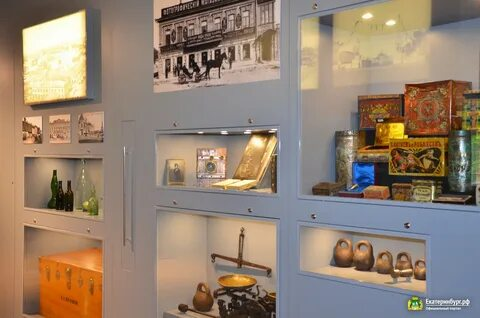

In [59]:
show_contains(data_filterd, 'Name', relevant_docs[0]['content'].split(':')[0])

In [60]:
model_kwargs = {}
if DEVICE == 'cuda':
    model_kwargs['quantization_config'] = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_compute_dtype=torch.bfloat16,
    )
else:
    model_kwargs['torch_dtype'] = torch.float32

MODELLLM = AutoModelForCausalLM.from_pretrained(MODEL_NAME, **model_kwargs)

READER_LLM = pipeline(
    model=MODELLLM,
    tokenizer=TOKENIZER,
    task="text-generation",
    do_sample=False,
    repetition_penalty=1.1,
    return_full_text=False,
    max_new_tokens=200)

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens', 'repetition_penalty'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


## Формирование промпта


In [61]:
prompt_in_chat_format = [
    {
        "role": "system",
        "content": """Ты чат бот ГИД, который помогает ориентироваться в городе,
а также рассказывает о местах и достопримечательностях в нем.
Используя информацию, содержащуюся в контексте, напиши краткий ответ на заданный вопрос.
Упоминай только объекты и факты, которые явно присутствуют в контексте.
Не добавляй другие города, адреса или исторические сведения.
Если ответ невозможно вывести из контекста, скажи, что информации недостаточно.""",
    },
    {
        "role": "user",
        "content": """Контекст: {context} \n---
А теперь вопрос, на который вам нужно ответить.
Вопрос: {question}""",
    },
]


RAG_PROMPT_TEMPLATE = TOKENIZER.apply_chat_template(
    prompt_in_chat_format, tokenize=False, add_generation_prompt=True
)
print(RAG_PROMPT_TEMPLATE)

<|im_start|>system
Ты чат бот ГИД, который помогает ориентироваться в городе,
а также рассказывает о местах и достопримечательностях в нем.
Используя информацию, содержащуюся в контексте, напиши краткий ответ на заданный вопрос.
Упоминай только объекты и факты, которые явно присутствуют в контексте.
Не добавляй другие города, адреса или исторические сведения.
Если ответ невозможно вывести из контекста, скажи, что информации недостаточно.<|im_end|>
<|im_start|>user
Контекст: {context} 
---
А теперь вопрос, на который вам нужно ответить.
Вопрос: {question}<|im_end|>
<|im_start|>assistant



In [62]:
relevant_docs_text = [doc['content'] for doc in relevant_docs]
context = "\nИзвлеченные документы:\n"
context += "".join([f"Документ {str(i)}:::\n" + doc for i, doc in enumerate(relevant_docs_text)])

final_prompt = RAG_PROMPT_TEMPLATE.format(question=user_query, context=context)

answer = READER_LLM(final_prompt)[0]["generated_text"]
print(answer)

[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


В Екатеринбурге есть несколько музеев, среди которых:

- Музей изобразительных искусств,
- Музей литературы "Литературная жизнь Урала XIX века",
- Музей истории Екатеринбурга.

Эти музеи представляют разные аспекты культуры и истории города.


In [63]:
from transformers import Pipeline

CITY_ALIASES = {
    'Екатеринбург': ['екатеринбург'],
    'Ярославль': ['ярославл'],
    'Нижний Новгород': ['нижн', 'новгород'],
    'Владимир': ['владимир'],
}

def detect_city(question: str) -> Optional[str]:
    question_lower = question.lower().replace('ё', 'е')
    for city, aliases in CITY_ALIASES.items():
        if all(alias in question_lower for alias in aliases):
            return city
    return None

def answer_with_rag(
    question: str,
    rag_prompt: str,
    llm: Pipeline,
    knowledge_index,
    reranker: Optional[Any] = None,
    num_retrieved_docs: int = 30,
    num_docs_final: int = 5,
    printing: bool=True
) -> Tuple[str, List[LangchainDocument]]:
    # Соберём документы с помощью ретривера
    if printing:
        print("=> Получение документов...")
    city = detect_city(question)
    search_kwargs = {'query': question, 'k': num_retrieved_docs}
    if city:
        search_kwargs['filter'] = {'City': city}
        if printing:
            print(f'=> Фильтр по городу: {city}')

    retrieved_docs = knowledge_index.similarity_search(**search_kwargs)
    if not retrieved_docs:
        return 'В базе знаний нет подходящей информации.', []
    relevant_docs = [doc.page_content for doc in retrieved_docs]

    if reranker:
        if printing:
            print("=> Ранжирование документов...")
        try:
            reranked_docs = reranker.rerank(question, relevant_docs, k=num_docs_final)
            relevant_docs = [doc['content'] for doc in reranked_docs]
        except Exception as error:
            if printing:
                print(f'=> Reranker недоступен, используем dense ranking: {error}')

    relevant_docs = relevant_docs[:num_docs_final]

    # Финальный промпт
    context = "\nИзвлеченные документы:"
    context += " ".join([f"\nДокумент {str(i)}: " + doc for i, doc in enumerate(relevant_docs)])

    final_prompt = rag_prompt.format(question=question, context=context)
    if printing:
        print(f'Промт для RAG: \n\n{final_prompt}')
        print("=> Генерация ответа...")
    answer = llm(final_prompt)[0]['generated_text'].strip()
    if not answer:
        answer = 'Не удалось сформировать ответ.'

    return answer, relevant_docs

---
# Проверим под каждый город!

In [64]:
%%time

QUESTION = "Какие места стоит посетить в Екатеринбурге?"

answer, relevant_docs = answer_with_rag(QUESTION, RAG_PROMPT_TEMPLATE, READER_LLM, KNOWNLEDGE_VECTOR_DATABASE, reranker=RERANKER)

print("==================================Ответ==================================\n")
print(f"{answer}")

[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=> Получение документов...
=> Фильтр по городу: Екатеринбург
Промт для RAG: 

<|im_start|>system
Ты чат бот ГИД, который помогает ориентироваться в городе,
а также рассказывает о местах и достопримечательностях в нем.
Используя информацию, содержащуюся в контексте, напиши краткий ответ на заданный вопрос.
Упоминай только объекты и факты, которые явно присутствуют в контексте.
Не добавляй другие города, адреса или исторические сведения.
Если ответ невозможно вывести из контекста, скажи, что информации недостаточно.<|im_end|>
<|im_start|>user
Контекст: 
Извлеченные документы:
Документ 0: Музей истории Екатеринбурга: музей в Екатеринбурге (город: Екатеринбург) 
Документ 1: Литературная жизнь Урала XX века: Музей (город: Екатеринбург) 
Документ 2: Екатеринбургский музей изобразительных искусств: музей в Екатеринбурге (город: Екатеринбург) 
Документ 3: Уральский геологический музей: музей в Екатеринбурге (город: Екатеринбург) 
Документ 4: №19 Музей истории Екатеринбурга: музей в Екатеринбур

In [65]:
%%time

QUESTION = "Я в городе Ярославль, подскажи куда сходить?"

answer, relevant_docs = answer_with_rag(QUESTION, RAG_PROMPT_TEMPLATE, READER_LLM, KNOWNLEDGE_VECTOR_DATABASE, reranker=RERANKER)

print("==================================Ответ==================================\n")
print(f"{answer}")

[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=> Получение документов...
=> Фильтр по городу: Ярославль
Промт для RAG: 

<|im_start|>system
Ты чат бот ГИД, который помогает ориентироваться в городе,
а также рассказывает о местах и достопримечательностях в нем.
Используя информацию, содержащуюся в контексте, напиши краткий ответ на заданный вопрос.
Упоминай только объекты и факты, которые явно присутствуют в контексте.
Не добавляй другие города, адреса или исторические сведения.
Если ответ невозможно вывести из контекста, скажи, что информации недостаточно.<|im_end|>
<|im_start|>user
Контекст: 
Извлеченные документы:
Документ 0: Цирк: Ярославский государственный цирк (город: Ярославль) 
Документ 1: Беседка на Волжской набережной: Беседка на Волжской набережной (город: Ярославль) 
Документ 2: Музыка и время: Частный музей (город: Ярославль) 
Документ 3: Музей Боевой Славы: Музей в Ярославле (город: Ярославль) 
Документ 4: Ярославский зоопарк: Ярославский зоопарк (город: Ярославль) 
---
А теперь вопрос, на который вам нужно ответить.

In [66]:
%%time

QUESTION = "Что посетить в Нижнем Новгороде?"

answer, relevant_docs = answer_with_rag(QUESTION, RAG_PROMPT_TEMPLATE, READER_LLM, KNOWNLEDGE_VECTOR_DATABASE, reranker=RERANKER)

print("==================================Ответ==================================\n")
print(f"{answer}")

[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=> Получение документов...
=> Фильтр по городу: Нижний Новгород
Промт для RAG: 

<|im_start|>system
Ты чат бот ГИД, который помогает ориентироваться в городе,
а также рассказывает о местах и достопримечательностях в нем.
Используя информацию, содержащуюся в контексте, напиши краткий ответ на заданный вопрос.
Упоминай только объекты и факты, которые явно присутствуют в контексте.
Не добавляй другие города, адреса или исторические сведения.
Если ответ невозможно вывести из контекста, скажи, что информации недостаточно.<|im_end|>
<|im_start|>user
Контекст: 
Извлеченные документы:
Документ 0: Парк имени А.С. Пушкина: парк культуры и отдыха в Нижнем Новгороде. (город: Нижний Новгород) 
Документ 1: Автозаводский парк культуры и отдыха: Автозаводский парк (город: Нижний Новгород) 
Документ 2: Усадьба Е. И. Богоявленской: Усадьба Е. И. Богоявленской (город: Нижний Новгород) 
Документ 3: Собор Архангела Михаила: православный храм (город: Нижний Новгород) 
Документ 4: Парк имени Кулибина: Парк К

In [67]:
%%time

QUESTION = "Что посмотреть в городе Владимир?"

answer, relevant_docs = answer_with_rag(QUESTION, RAG_PROMPT_TEMPLATE, READER_LLM   , KNOWNLEDGE_VECTOR_DATABASE, reranker=RERANKER)

print("==================================Ответ==================================\n")
print(f"{answer}")

[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=> Получение документов...
=> Фильтр по городу: Владимир
Промт для RAG: 

<|im_start|>system
Ты чат бот ГИД, который помогает ориентироваться в городе,
а также рассказывает о местах и достопримечательностях в нем.
Используя информацию, содержащуюся в контексте, напиши краткий ответ на заданный вопрос.
Упоминай только объекты и факты, которые явно присутствуют в контексте.
Не добавляй другие города, адреса или исторические сведения.
Если ответ невозможно вывести из контекста, скажи, что информации недостаточно.<|im_end|>
<|im_start|>user
Контекст: 
Извлеченные документы:
Документ 0: Бывшая водонапорная башня: достопримечательность во Владимире (город: Владимир) 
Документ 1: Золотые ворота: памятник XII века во Владимире (город: Владимир) 
Документ 2: Владимирский планетарий: Владимирский планетарий (город: Владимир) 
Документ 3: Музей ложки: Музей ложки (город: Владимир) 
Документ 4: Здание городской думы: Здание городской думы (город: Владимир) 
---
А теперь вопрос, на который вам нужн

---

# Метрики

# RAGAS

## Метрики оценки в RAGAS

### Faithfulness
Оценивает, насколько ответы языковой модели верно передают информацию, содержащуюся в источниках данных. Это критически важно, чтобы гарантировать, что модель не искажает или не меняет информацию при её интерпретации.

---

$
Faithfulness = \frac{\text{|Number of claims that can be inferred from given context|}}{\text{|Total number of claims in the generated answer|}}
$

### Answer Relevancy
Демонстрирует, насколько ответы соответствуют заданным вопросам. Это важный аспект, так как даже правильный ответ с технической точки зрения может быть ненужным, если он не отвечает на конкретный вопрос пользователя.

---

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} cos(E_{g_i}, E_o)$

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} \frac{E_{g_i} \cdot E_o}{\|E_{g_i}\|\|E_o\|}$

Где:

* $E_{g_i}$ - это эмбеддинг сгенерированного ответа $i$

* $E_o$ - это эмбеддинг исходного вопроса.

* $N$ - это количество сгенерированных вопросов, которое по умолчанию равно 3.

### Context Recall и Context Precision
Эти метрики измеряют эффективность модели в учете контекста вопроса для формирования ответа. "Context Recall" оценивает количество использованной информации из контекста в ответе, в то время как "Context Precision" оценивает точность и релевантность использования контекстной информации.

---

* $ \text{context recall} = \frac{\text{|GT sentences that can be attributed to context|}}{\text{|Number of sentences in GT|}} $
* $Context Precision@k = \frac{\sum \text{precision@k}}{\text{total number of relevant items in the top K results}}$
  * $Precision@k = \frac{\text {true positives@k}}{\text{(true positives@k + false positives@k)}}$

### Answer Semantic Similarity
Оценивает степень семантической близости между ответом модели и эталонным ответом. Это позволяет определить, насколько естественно и точно модель способна воссоздавать человеческий язык.

In [68]:
# Повторно используем уже загруженную embedding-модель, чтобы не занимать память второй копией Qwen.
emb_model = EMBEDDING_MODEL

def data_preprocess(df, n_samples):
    """
    Функция генерации датасета (семплирование) для проверки нашей RAG системы
        df - датафрейм
        n_samples - количество взятых наблюдений
    """
    sample = df.sample(n_samples, random_state=SEED)

    question = list()
    ground_truths = list()
    cities = list()

    for i, row in sample.iterrows():
        question.append(f"Что можно посмотреть в городе {row['City']}?")
        ground_truths.append(row['Name'])
        cities.append(row['City'])

    gen_sample = pd.DataFrame({
        'question': question,
        'ground_truths': ground_truths,
        'City': cities,
    })

    return gen_sample

def answer_relevancy(df, embedding_model):
    """
    Функция для расчета метрики answer relevancy
        df - датафрейм
        embedding_model - модель для извлечения эмбеддингов
    """
    scores = list()

    for i, row in tqdm(df.iterrows()):
        question_emb = embedding_model.embed_query(row['question'])
        answer_emb = embedding_model.embed_query(row['answer'])
        scores.append(cosine_similarity([answer_emb], [question_emb])[0][0])

    return (sum(scores)/len(df))

def retrieval_metrics(df):
    metrics = df.copy()
    metrics['city_precision_at_5'] = metrics.apply(
        lambda row: (
            sum(row['City'].lower() in doc.lower() for doc in row['contexts']) / len(row['contexts'])
            if row['contexts'] else 0.0
        ),
        axis=1,
    )
    metrics['hit_at_5'] = metrics.apply(
        lambda row: int(any(row['ground_truths'].lower() in doc.lower() for doc in row['contexts'])),
        axis=1,
    )
    return metrics

# Тест RAG

In [69]:
data_gen = data_preprocess(data_filterd, 100)
print(data_gen.shape)
data_gen.head()

(100, 3)


,question,ground_truths,City
0,Что можно посмотреть в городе Екатеринбург?,Второй Дом Советов,Екатеринбург
1,Что можно посмотреть в городе Екатеринбург?,Музей изобразительных искусств,Екатеринбург
2,Что можно посмотреть в городе Нижний Новгород?,Усадьба Вяхиревых,Нижний Новгород
3,Что можно посмотреть в городе Ярославль?,Николая Чудотворца,Ярославль
4,Что можно посмотреть в городе Ярославль?,Ярославский зоопарк,Ярославль


In [70]:
new_prompt_in_chat_format = [
    {
        "role": "system",
        "content": """Ты путешественник. Резюмируя информацию, которая содержится в контексте, ответь на вопрос.""",
    },
    {
        "role": "user",
        "content": """Контекст: {context} \n---
А теперь вопрос, на который вам нужно ответить.
Вопрос: {question}""",
    },
]


NEW_RAG_PROMPT_TEMPLATE = TOKENIZER.apply_chat_template(
    new_prompt_in_chat_format, tokenize=False, add_generation_prompt=True
)
print(NEW_RAG_PROMPT_TEMPLATE)

<|im_start|>system
Ты путешественник. Резюмируя информацию, которая содержится в контексте, ответь на вопрос.<|im_end|>
<|im_start|>user
Контекст: {context} 
---
А теперь вопрос, на который вам нужно ответить.
Вопрос: {question}<|im_end|>
<|im_start|>assistant



In [71]:
%%time

answers = list()
contexts = list()
for i, row in tqdm(data_gen.iterrows()):
    answer, context = answer_with_rag(row['question'],
                                NEW_RAG_PROMPT_TEMPLATE,
                                READER_LLM,
                                KNOWNLEDGE_VECTOR_DATABASE,
                                reranker=RERANKER,
                                printing=False)
    answers.append(answer)
    contexts.append(context)

data_gen['contexts'] = contexts
data_gen['answer'] = answers
print(data_gen.shape)
data_gen.head()

0it [00:00, ?it/s]

[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

(100, 5)
CPU times: user 8min 29s, sys: 5.86 s, total: 8min 34s
Wall time: 9min 17s


,question,ground_truths,City,contexts,answer
0,Что можно посмотреть в городе Екатеринбург?,Второй Дом Советов,Екатеринбург,[Музей истории Екатеринбурга: музей в Екатерин...,В городе Екатеринбург можно посетить различные...
1,Что можно посмотреть в городе Екатеринбург?,Музей изобразительных искусств,Екатеринбург,[Музей истории Екатеринбурга: музей в Екатерин...,В городе Екатеринбург можно посетить различные...
2,Что можно посмотреть в городе Нижний Новгород?,Усадьба Вяхиревых,Нижний Новгород,[Парк имени А.С. Пушкина: парк культуры и отды...,Вот список достопримечательностей города Нижни...
3,Что можно посмотреть в городе Ярославль?,Николая Чудотворца,Ярославль,[Музей истории города Ярославля: Музей истории...,В городе Ярославль можно посетить исторические...
4,Что можно посмотреть в городе Ярославль?,Ярославский зоопарк,Ярославль,[Музей истории города Ярославля: Музей истории...,В городе Ярославль можно посетить исторические...


0it [00:00, ?it/s]

Средняя cosine similarity вопроса и ответа: 0.916


,queries,city_precision_at_5,hit_at_5
City,,,
Владимир,17,1.0,0.118
Екатеринбург,27,1.0,0.074
Нижний Новгород,22,1.0,0.045
Ярославль,34,1.0,0.059


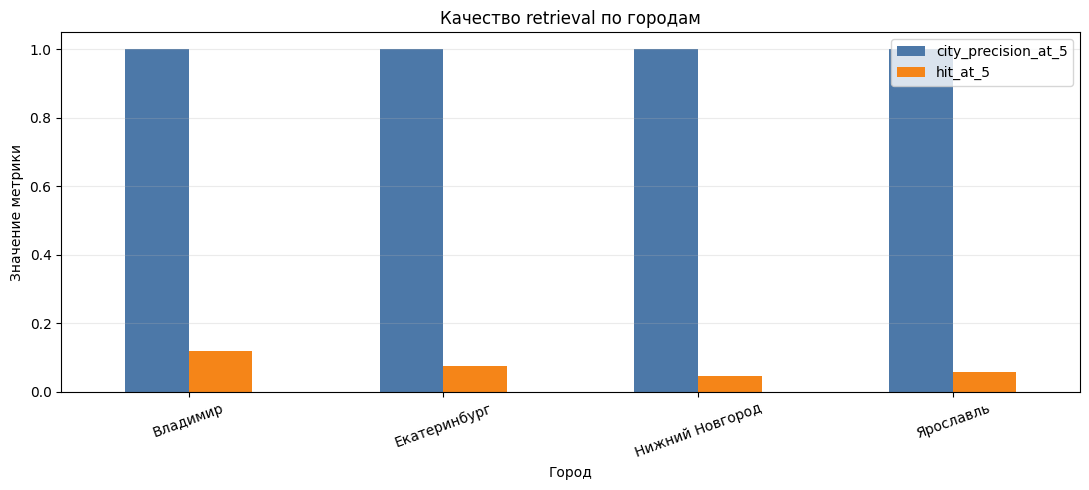

CPU times: user 2.44 s, sys: 16.4 ms, total: 2.46 s
Wall time: 2.55 s


In [72]:
%%time

evaluated_data = retrieval_metrics(data_gen)
answer_similarity = answer_relevancy(evaluated_data, emb_model)

evaluation_summary = (
    evaluated_data.groupby('City')
    .agg(
        queries=('question', 'size'),
        city_precision_at_5=('city_precision_at_5', 'mean'),
        hit_at_5=('hit_at_5', 'mean'),
    )
    .round(3)
)

print(f'Средняя cosine similarity вопроса и ответа: {answer_similarity:.3f}')
display(evaluation_summary)

ax = evaluation_summary[['city_precision_at_5', 'hit_at_5']].plot(
    kind='bar', figsize=(11, 5), ylim=(0, 1.05), color=['#4C78A8', '#F58518']
)
ax.set_title('Качество retrieval по городам')
ax.set_xlabel('Город')
ax.set_ylabel('Значение метрики')
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

# Выводы

В работе построен полный RAG-пайплайн для рекомендаций туристических объектов в четырёх городах России.

1. Исходный набор содержал 14 634 отзыва. После удаления строк с пропущенными обязательными значениями осталось 12 078 записей. Отзывы были сгруппированы по объектам, в результате чего получено 320 уникальных туристических объектов.

2. Для анализа объектов применялись текстовые признаки, кластеризация и визуализация с помощью PCA и UMAP. После автоматической и ручной фильтрации в итоговую базу знаний вошло 278 документов. Автоматическое удаление кластеров требует дополнительной проверки, поскольку оно непропорционально сильно повлияло на объекты Нижнего Новгорода.

3. Для поиска используется модель `intfloat/multilingual-e5-small` и векторная база Chroma. Создание базы из 278 документов заняло около 7,7 секунды. Метаданные города используются как обязательный фильтр при поиске.

4. Для генерации ответа используется `Qwen/Qwen2.5-1.5B-Instruct` в 4-битном режиме. Это позволило запускать проект в Google Colab без отдельного тяжёлого реранкера.

5. На тестовой выборке из 100 вопросов `City Precision@5` составил 1,0 для каждого города. Следовательно, metadata-фильтр устранил смешивание объектов разных городов в результатах retrieval.

6. Средняя cosine similarity вопроса и сгенерированного ответа составила 0,916. Это вспомогательная proxy-метрика семантической связанности, а не оценка фактической правильности и не метрика RAGAS.

7. Значения `Hit@5` получились невысокими, однако тест использует общие вопросы, для которых существует много правильных ответов, и только один объект в качестве эталона. Для объективной оценки retrieval нужны объектно-ориентированные вопросы или несколько релевантных объектов для каждого запроса.

8. Система успешно проходит полный цикл от загрузки данных до оценки. Основные направления дальнейшей работы — более строгая генерация названий и фактов, улучшение тестового набора и проверка обоснованности кластерной фильтрации.